Parameters:
mu = 0.29616069521840294
alpha = 0.9077814976343077
beta = 1.6945192870597965

Transformed waiting times:
--------------------------
Mean: 1.0004241803619036
Variance: 0.9433520758261196


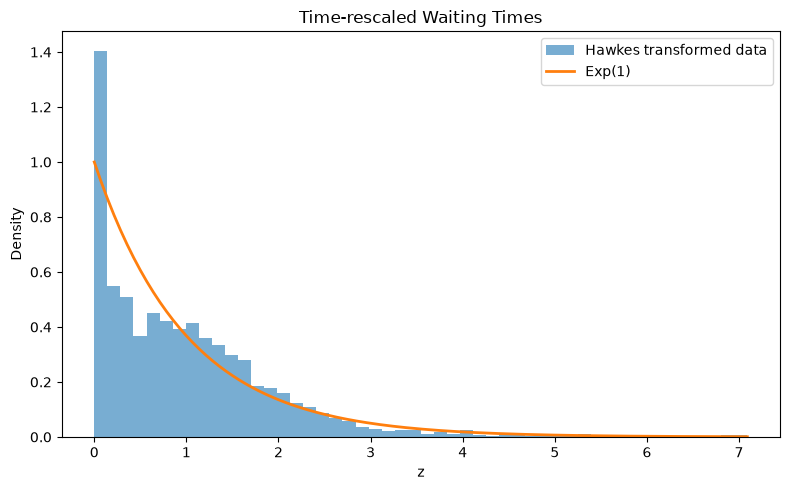


KS test
----------------
Statistic: 0.06755223998480825
p-value: 1.152052112479176e-09


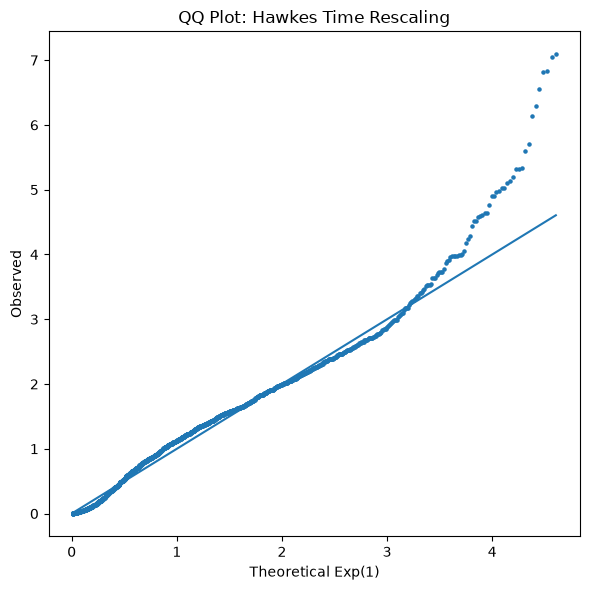


Conclusion:

A Poisson process is clearly inadequate. A simple Hawkes process captures much of the clustering, but a 
more realistic earthquake model should include magnitude-dependent triggering and/or a non-exponential kernel.




In [1]:
# ==============================================================
# Notebook 5: Hawkes Goodness-of-Fit
#
# Goal:
# - Validate fitted Hawkes model
# - Use time-rescaling theorem
# - Check if transformed waiting times follow Exp(1)
#
# For a correct model:
#
# z_i = integral(lambda(t))dt
#
# should satisfy:
#
# z_i ~ Exponential(1)
#
# ==============================================================


# --------------------------------------------------------------
# 1. Imports
# --------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import expon, kstest

from src.hawkes import intensity


# --------------------------------------------------------------
# 2. Load data
# --------------------------------------------------------------

df = pd.read_csv(
    "../data/earthquakes_greece_2016_2026.csv"
)

df["time"] = pd.to_datetime(df["time"])

df = (
    df
    .sort_values("time")
    .reset_index(drop=True)
)


# Convert to days

t0 = df["time"].iloc[0]

times = (
    df["time"] - t0
).dt.total_seconds() / (24 * 3600)

times = times.values


# --------------------------------------------------------------
# 3. Load fitted Hawkes parameters
# --------------------------------------------------------------

mu, alpha, beta = np.load(
    "../data/hawkes_params.npy"
)


print("Parameters:")
print("mu =", mu)
print("alpha =", alpha)
print("beta =", beta)


# --------------------------------------------------------------
# 4. Compute time-rescaled intervals
# --------------------------------------------------------------
#
# Integral of Hawkes intensity:
#
# ∫ lambda(t)dt
#
# between two earthquakes.
#
# For interval (ti-1, ti):
#
# mu*dt
#
# +
#
# sum(alpha/beta *
# (exp(-beta*(ti-1-tj))
# -
# exp(-beta*(ti-tj))))
#
# --------------------------------------------------------------


z = []


for i in range(1, len(times)):

    t_previous = times[i-1]
    t_current = times[i]


    dt = t_current - t_previous


    # background contribution

    integral = mu * dt


    # triggering contribution

    history = times[:i]


    if len(history) > 0:

        integral += np.sum(
            (
                alpha / beta
            )
            *
            (
                np.exp(
                    -beta *
                    (t_previous - history)
                )
                -
                np.exp(
                    -beta *
                    (t_current - history)
                )
            )
        )


    z.append(integral)



z = np.array(z)


# --------------------------------------------------------------
# 5. Statistics
# --------------------------------------------------------------

print("\nTransformed waiting times:")
print("--------------------------")

print("Mean:", z.mean())
print("Variance:", z.var())


# --------------------------------------------------------------
# 6. Histogram vs Exp(1)
# --------------------------------------------------------------

x = np.linspace(
    0,
    max(z),
    200
)


plt.figure(figsize=(8,5))


plt.hist(
    z,
    bins=50,
    density=True,
    alpha=0.6,
    label="Hawkes transformed data"
)


plt.plot(
    x,
    expon.pdf(x),
    linewidth=2,
    label="Exp(1)"
)


plt.xlabel("z")
plt.ylabel("Density")

plt.title(
    "Time-rescaled Waiting Times"
)

plt.legend()

plt.tight_layout()
plt.show()


# --------------------------------------------------------------
# 7. Kolmogorov-Smirnov test
# --------------------------------------------------------------
#
# H0:
# z comes from Exp(1)
#
# Large p-value means we cannot reject the model.
#

ks_stat, p_value = kstest(
    z,
    "expon"
)


print("\nKS test")
print("----------------")

print("Statistic:", ks_stat)
print("p-value:", p_value)


# --------------------------------------------------------------
# 8. QQ plot
# --------------------------------------------------------------

sorted_z = np.sort(z)

theoretical = expon.ppf(
    np.linspace(
        0.01,
        0.99,
        len(z)
    )
)


plt.figure(figsize=(6,6))

plt.scatter(
    theoretical,
    sorted_z,
    s=5
)


plt.plot(
    theoretical,
    theoretical
)


plt.xlabel("Theoretical Exp(1)")
plt.ylabel("Observed")

plt.title(
    "QQ Plot: Hawkes Time Rescaling"
)

plt.tight_layout()
plt.show()


# --------------------------------------------------------------
# Conclusion
# --------------------------------------------------------------

print("""
Conclusion:

A Poisson process is clearly inadequate. A simple Hawkes process captures much of the clustering, but a 
more realistic earthquake model should include magnitude-dependent triggering and/or a non-exponential kernel.

""")